In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/hantavirus_outbreaks.csv
/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/hantavirus_country_yearly.csv
/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/data_dictionary.csv
/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/hantavirus_clinical.csv
/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/hantavirus_environmental.csv
/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/sources_metadata.csv
/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/hantavirus_virus_strains.csv
/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/hantavirus_master.csv
/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/Hantavirus_Andes_Global_Registry.csv
/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidem

In [2]:
df = pd.read_csv('/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/hantavirus_country_yearly.csv')
df.head()

,year,iso3,country,who_region,latitude,longitude,syndrome,confirmed_cases,deaths,recovered,case_fatality_rate,hospitalized,icu_admissions,human_to_human_cases
0,1993,ARG,Argentina,AMRO,-34.6,-58.4,HPS,35,11,24,0.3426,30,8,0
1,1993,CHL,Chile,AMRO,-33.4,-70.6,HPS,0,0,0,0.2587,0,0,0
2,1993,BRA,Brazil,AMRO,-15.8,-47.9,HPS,0,0,0,0.4455,0,0,0
3,1993,BOL,Bolivia,AMRO,-16.5,-68.2,HPS,0,0,0,0.2775,0,0,0
4,1993,PRY,Paraguay,AMRO,-25.3,-57.6,HPS,0,0,0,0.2666,0,0,0


In [ ]:
df.describe()

In [ ]:
df.isnull().sum()

In [ ]:
print(df.columns.dtype)

In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['iso3'] = le.fit_transform(df['iso3'])
df['country'] = le.fit_transform(df['country'])
df['who_region'] = le.fit_transform(df['who_region'])
df['syndrome'] = le.fit_transform(df['syndrome'])

In [4]:
print(df.dtypes)

year                      int64
iso3                      int64
country                   int64
who_region                int64
latitude                float64
longitude               float64
syndrome                  int64
confirmed_cases           int64
deaths                    int64
recovered                 int64
case_fatality_rate      float64
hospitalized              int64
icu_admissions            int64
human_to_human_cases      int64
dtype: object


In [5]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum().sum()

In [ ]:
df.head()
df.tail()

In [6]:
df['icu_to_hospital_ratio'] = df['icu_admissions'] / (df['hospitalized'] + 1e-5)
df['hospitalization_rate'] = df['hospitalized'] / (df['confirmed_cases'] + 1e-5)
df['distance_from_equator'] = df['latitude'].abs()
df['is_northern_hemisphere'] = (df['latitude'] > 0).astype(int)
region_fatality = df.groupby('who_region')['case_fatality_rate'].transform('mean')
df['region_avg_fatality'] = region_fatality
df['syndrome_region'] = df['syndrome'].astype(str) + "_" + df['who_region'].astype(str)
df['h2h_intensity'] = df['confirmed_cases'] * df['human_to_human_cases']


In [7]:
y = df['deaths']
X = df.drop(['deaths', 'human_to_human_cases'], axis=1)
print(X.shape)
print(X.columns.to_list())

(850, 19)
['year', 'iso3', 'country', 'who_region', 'latitude', 'longitude', 'syndrome', 'confirmed_cases', 'recovered', 'case_fatality_rate', 'hospitalized', 'icu_admissions', 'icu_to_hospital_ratio', 'hospitalization_rate', 'distance_from_equator', 'is_northern_hemisphere', 'region_avg_fatality', 'syndrome_region', 'h2h_intensity']


In [9]:
from sklearn.model_selection import train_test_split
train_X , val_X , train_y , val_y = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=500, max_depth=5, max_sample = 0.5, random_state=42)
model.fit(train_X, train_y)

from sklearn.metrics import mean_absolute_error, r2_score
prediction = model.predict(val_X)

mae = mean_absolute_error(val_y, prediction)
r2 = r2_score(val_y, prediction)

print(f'MAE for RFC is {mae:.2f}')
print(f'R2 Score: {r2:.4f}')


TypeError: RandomForestRegressor.__init__() got an unexpected keyword argument 'subsample'

In [26]:
from xgboost import XGBRegressor


train_X['syndrome_region'] = train_X['syndrome_region'].astype('category')
val_X['syndrome_region'] = val_X['syndrome_region'].astype('category')

model = XGBRegressor(
    n_estimators=500, 
    max_depth=5, 
    subsample=0.5,
    random_state=42,
    enable_categorical=True
)

model.fit(train_X, train_y)

from sklearn.metrics import mean_absolute_error, r2_score
prediction = model.predict(val_X)

mae = mean_absolute_error(val_y, prediction)
r2 = r2_score(val_y, prediction)

print(f'MAE for XGB: {mae:.2f}')
print(f'R2 Score: {r2:.4f}')

MAE for XGB: 3.89
R2 Score: 0.9657


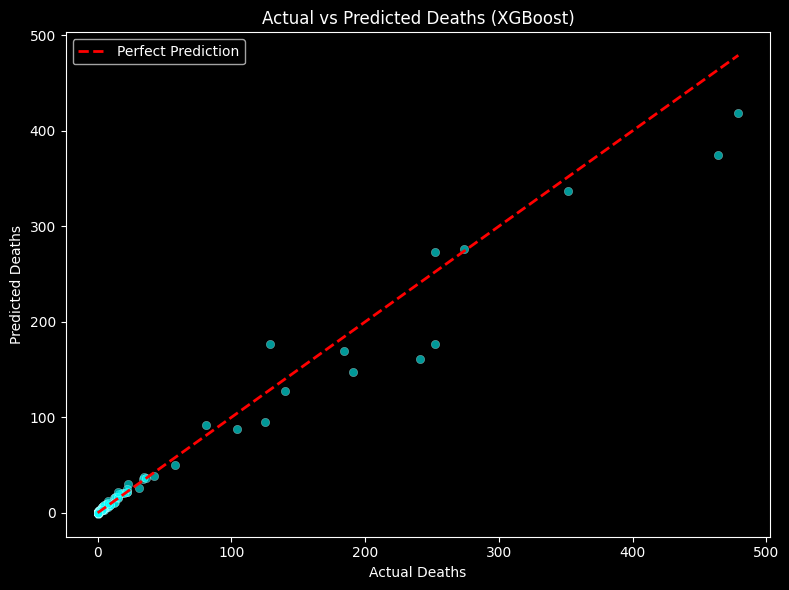

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(figsize=(8,6), facecolor='black')
ax.set_facecolor('black')

ax.scatter(val_y, prediction, alpha=0.6, color='cyan', edgecolors='white', linewidths=0.3)
ax.plot([val_y.min(), val_y.max()],
        [val_y.min(), val_y.max()],
        'r--', lw=2, label='Perfect Prediction')

ax.set_xlabel('Actual Deaths', color='white')
ax.set_ylabel('Predicted Deaths', color='white')
ax.set_title('Actual vs Predicted Deaths (XGBoost)', color='white')
ax.tick_params(colors='white')
ax.spines[:].set_color('white')
ax.legend(facecolor='black', labelcolor='white')

plt.tight_layout()
plt.show()

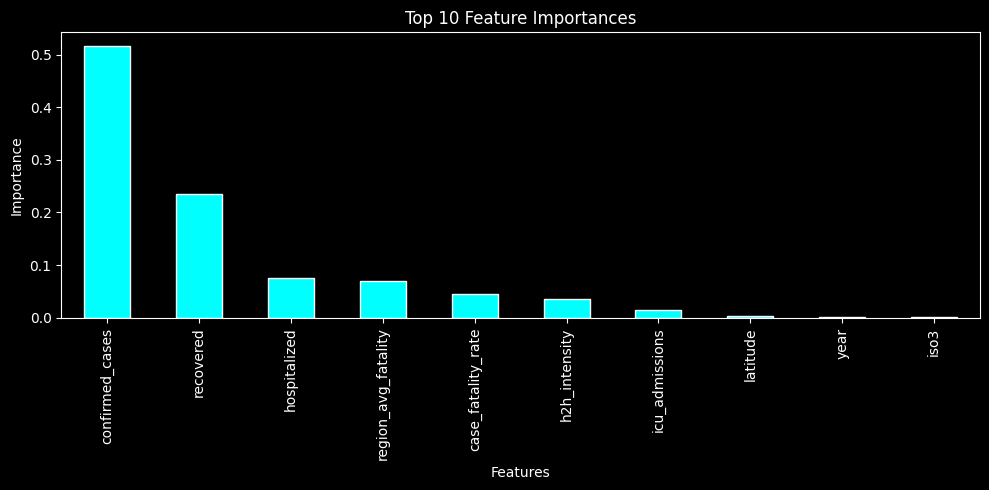

In [30]:
feat_imp = pd.Series(model.feature_importances_,
                     index=train_X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,5), facecolor='black')
ax.set_facecolor('black')

feat_imp.head(10).plot(kind='bar', ax=ax, color='cyan', edgecolor='white')

ax.set_title('Top 10 Feature Importances', color='white')
ax.set_xlabel('Features', color='white')
ax.set_ylabel('Importance', color='white')
ax.tick_params(colors='white', axis='both')
ax.spines[:].set_color('white')

plt.tight_layout()
plt.show()